# Customer Total Spend Prediction
### `Total_Spend` is predicted for online retail customers using Linear Regression

In this project, a Linear Regression model is built to predict `Total_Spend`, a continuous variable, using customer demographic and behavioural data from `data_online_retail_customers.csv`.


#### Load the dependencies
The libraries needed to manipulate data, split it into training and testing sets, build the model, and evaluate its performance are loaded first.

* pandas — used for data manipulation and analysis.
* train_test_split — used to split the data into training and testing sets.
* LinearRegression — the model used to predict the continuous target variable.
* mean_absolute_error and mean_squared_error — used to evaluate model performance.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn import preprocessing
import matplotlib.pyplot as plt

#### Load the data
`data_online_retail_customers.csv` is loaded directly.


In [2]:
# Load the data
data = pd.read_csv("data_online_retail_customers.csv")

The CSV file is read and stored in a DataFrame called `data`, using pandas' `read_csv` function.

#### Clean the data

Before modelling, the dataset is checked for missing values.


In [3]:
# Check for missing values
missing_values = data.isna()
print(missing_values.any().any())

False


No missing values are found in the dataset, confirmed by the `False` result above.

If missing values had been found, the affected rows would be dropped using the code below.


In [4]:
# Remove rows with missing values
data = data.dropna()

#### Check data types
The data types of all variables in the dataset are checked.


In [5]:
# Print the data type of all variables
print(data.dtypes)

Customer_ID                  int64
Age                          int64
Gender                         str
Annual_Income              float64
Total_Spend                float64
Years_as_Customer            int64
Num_of_Purchases             int64
Num_of_Returns               int64
Num_of_Support_Contacts      int64
Satisfaction_Score           int64
Last_Purchase_Days_Ago       int64
Email_Opt_In                  bool
Promotion_Response             str
Churned                       bool
dtype: object


`Gender` and `Promotion_Response` are found to be stored as text (`object`) columns. These are converted into categorical variables before proceeding.

#### Data transformation


In [6]:
# Convert categorical columns to 'category' dtype
data['Gender'] = data['Gender'].astype('category')
data['Promotion_Response'] = data['Promotion_Response'].astype('category')

The text data is now stored as categorical data. The transformation is confirmed to have been applied correctly — `Gender` and `Promotion_Response` are now categorical variables.


In [7]:
# Print the data type of all variables
print(data.dtypes)

Customer_ID                   int64
Age                           int64
Gender                     category
Annual_Income               float64
Total_Spend                 float64
Years_as_Customer             int64
Num_of_Purchases              int64
Num_of_Returns                int64
Num_of_Support_Contacts       int64
Satisfaction_Score            int64
Last_Purchase_Days_Ago        int64
Email_Opt_In                   bool
Promotion_Response         category
Churned                        bool
dtype: object


The categorical variables are also converted into dummy (indicator) variables, for use in the regression model.


In [8]:
# Convert categorical variables to dummy variables
data = pd.get_dummies(data, drop_first=True)

The dummy variable transformation is confirmed to have been applied correctly.


In [9]:
# Print the data type of all variables
print(data.dtypes)

Customer_ID                          int64
Age                                  int64
Annual_Income                      float64
Total_Spend                        float64
Years_as_Customer                    int64
Num_of_Purchases                     int64
Num_of_Returns                       int64
Num_of_Support_Contacts              int64
Satisfaction_Score                   int64
Last_Purchase_Days_Ago               int64
Email_Opt_In                          bool
Churned                               bool
Gender_Male                           bool
Promotion_Response_Responded          bool
Promotion_Response_Unsubscribed       bool
dtype: object


#### Feature selection

Linear regression is used to understand the relationship between a target variable and one or more predictor variables.

`Total_Spend` is predicted using the other customer attributes as predictors. `Customer_ID` is excluded, as it is simply a unique identifier and carries no information about purchase behaviour, preferences, or spending patterns. All remaining variables are used as inputs.

The data is split into input variables (X) and the target variable (y).


In [10]:
# Split the data into inputs (X) and outputs (y)
X = data.drop(columns=['Customer_ID', 'Total_Spend'])
y = data["Total_Spend"]

#### Preprocess the data (scaling)

The numeric features are scaled to help the model perform well. Scaling normalises the data so that no single feature dominates purely because of its range.


In [11]:
# Scale the numeric input data
# Identify numeric columns
numeric_columns = X.select_dtypes(include=['float64', 'int64']).columns

# Scale numeric columns
scaler = preprocessing.StandardScaler().fit(X[numeric_columns])
X[numeric_columns] = scaler.transform(X[numeric_columns])

#### Split data into training and testing sets

The data is split into training and testing sets (80/20) to evaluate how well the model generalises to unseen data. `random_state=42` is fixed so the results are reproducible.


In [12]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Train a linear regression model

A linear regression model is created and trained on the training data.


In [13]:
# Train a linear regression model on the training data
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Make predictions

Once trained, the model is used to make predictions on the testing data.


In [14]:
# Make predictions
predictions = model.predict(X_test)

#### Evaluate the model

The model's performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared.


In [15]:
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, predictions)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

# Calculate R-squared
r_squared = model.score(X_test, y_test)

# Print evaluation metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared: {r_squared}")

Mean Absolute Error (MAE): 2443.5588433286866
Root Mean Squared Error (RMSE): 2777.9891546137032
R-squared: -0.03510137107000055


#### Plot actual vs predicted values

Finally, actual vs. predicted values are visualised to see how closely the model's predictions align with the real data.


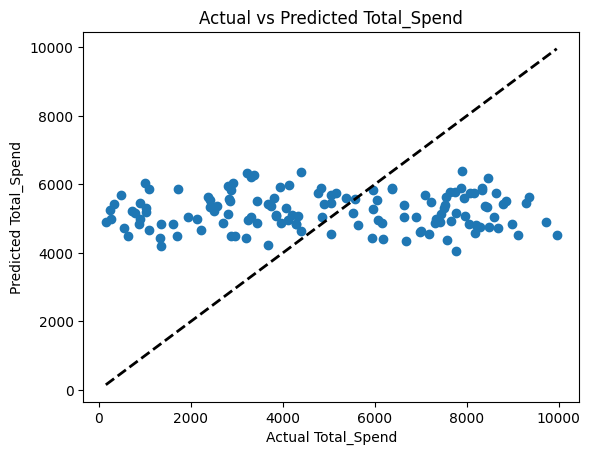

In [16]:
# Plot actual vs predicted values
plt.scatter(y_test, predictions)
plt.xlabel("Actual Total_Spend")
plt.ylabel("Predicted Total_Spend")
plt.title("Actual vs Predicted Total_Spend")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

#### Interpreting model performance

The results are illustrated in the scatter plot of actual vs. predicted `Total_Spend` above. Each point represents a pair of actual spend (x-axis) and predicted spend (y-axis). The black dashed line represents perfect prediction, where predicted values exactly match actual values.

* Spread of points: the wider the spread from the dashed line, the larger the prediction error.
* Under/overestimation: points below the line indicate the model underestimated spend; points above indicate overestimation.

**Mean Absolute Error (MAE): 2443.56** — predictions are off by an average of about 2,444 units of total spend.

**Root Mean Squared Error (RMSE): 2777.99** — larger errors are penalised more heavily here than in MAE; a typical error magnitude of around 2,778 units is indicated.

**R-squared: -0.035** — a negative R² means the model performs worse than simply predicting the average spend for every customer. Little to no linear relationship between these features and `Total_Spend` is being captured.

A poor fit for this data is shown by a simple linear regression. A non-linear relationship, factors not captured in the dataset, or limited underlying signal in the data itself (common in synthetic/practice datasets like this one) may be responsible. Testing non-linear models (e.g. Random Forest, Gradient Boosting) would be a useful next step.

#### Interpreting the feature coefficients

Even though weak overall predictive power is shown by the model, the coefficients can still be examined to see which features move `Total_Spend` up or down within the (limited) linear relationship found.


In [17]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print(coefficients)

                            Feature  Coefficient
0                               Age   -40.202190
1                     Annual_Income  -101.897688
2                 Years_as_Customer   210.481450
3                  Num_of_Purchases   239.735986
4                    Num_of_Returns    26.078472
5           Num_of_Support_Contacts  -237.984130
6                Satisfaction_Score   -70.121477
7            Last_Purchase_Days_Ago    31.835516
8                      Email_Opt_In   311.263549
9                           Churned   182.185401
10                      Gender_Male  -305.706584
11     Promotion_Response_Responded  -399.230381
12  Promotion_Response_Unsubscribed  -689.450493


#### Discussion of results: feature coefficients

A table of feature names and their coefficients is generated by the code above. The larger the absolute value of a coefficient, the more that feature moves the prediction — `Total_Spend` is pushed up by positive coefficients and pushed down by negative ones.

Given that a negative R² is obtained, these coefficients should be read cautiously — patterns picked up by the model are described here, rather than necessarily real, reliable drivers of spend. It's also worth noting that when this notebook is re-run with a different train/test split, the size — and even the sign — of individual coefficients can shift noticeably, a further sign that no stable relationship is being captured by the model.

**Largest positive coefficients**
* Email_Opt_In (+311.26) — customers opted into email marketing are associated with higher predicted spend.
* Num_of_Purchases (+239.74) — more frequent purchasers are associated with higher spend, as expected.
* Years_as_Customer (+210.48) — longer-tenured customers are associated with higher spend.
* Churned (+182.19) — churned customers are, counterintuitively, associated with higher spend; further investigation would be needed, and this may simply reflect noise given the model's poor fit.

**Largest negative coefficients**
* Promotion_Response_Unsubscribed (-689.45) — customers who unsubscribed from promotions are associated with substantially lower spend.
* Promotion_Response_Responded (-399.23) — somewhat counterintuitively, customers who responded to promotions are also associated with lower spend.
* Gender_Male (-305.71) — male customers are associated with lower predicted spend than female customers.
* Num_of_Support_Contacts (-237.98) — more support contacts are associated with lower spend, possibly reflecting dissatisfaction.
* Annual_Income (-101.90) — higher income is associated with slightly lower spend, which may suggest more conservative spending habits among higher earners.
* Satisfaction_Score (-70.12) — higher satisfaction is associated with slightly lower spend, a mild but counterintuitive effect.

The smallest-magnitude coefficients — Age (-40.20), Last_Purchase_Days_Ago (+31.84), and Num_of_Returns (+26.08) — are shown to have relatively little influence on the model's predictions.


#### Key takeaways

Given the negative R², these coefficients are treated as exploratory rather than conclusive. With that caveat:

* Features most positively associated with spend: Email_Opt_In, Num_of_Purchases, Years_as_Customer, and Churned.
* Features most negatively associated with spend: Promotion_Response_Unsubscribed, Promotion_Response_Responded, Gender_Male, and Num_of_Support_Contacts.

Overall, a plain linear regression is shown by this project to struggle in explaining `Total_Spend` from these features alone. Testing non-linear models to see whether more of the variance in customer spending can be captured would be the next step in this analysis.
